In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
# 1. Load and Scale Data
df = pd.read_csv('../datasets/crop_recommendation/Crop_recommendation.csv')
X = df.drop('label', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# 2. Define Models (Using 4 clusters as identified by your Elbow method)
n_clusters = 4
models = {
    "K-Means": KMeans(n_clusters=n_clusters, random_state=42),
    "Agglomerative": AgglomerativeClustering(n_clusters=n_clusters),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5) # DBSCAN doesn't take n_clusters
}

cluster_results = {}

print("--- Clustering Evaluation ---")
for name, model in models.items():
    labels = model.fit_predict(X_scaled)
    
    # DBSCAN might only find 1 cluster or all noise (-1), which prevents scoring
    if len(set(labels)) > 1:
        sil = silhouette_score(X_scaled, labels)
        dbi = davies_bouldin_score(X_scaled, labels)
        cluster_results[name] = {"Silhouette": sil, "DBI": dbi}
        print(f"{name} -> Silhouette: {sil:.4f}, DBI: {dbi:.4f}")
    else:
        print(f"{name} -> Failed to produce multiple clusters (check parameters).")

--- Clustering Evaluation ---


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", l

K-Means -> Silhouette: 0.2553, DBI: 1.3866
Agglomerative -> Silhouette: 0.2592, DBI: 1.4269
DBSCAN -> Silhouette: -0.0936, DBI: 1.4367


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [5]:
# 1. Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
# 2. Create the plotting labels
# (Re-running fit_predict just to ensure we have the labels for the plot)
labels_kmeans = models["K-Means"].fit_predict(X_scaled)
labels_agg = models["Agglomerative"].fit_predict(X_scaled)
labels_dbscan = models["DBSCAN"].fit_predict(X_scaled)

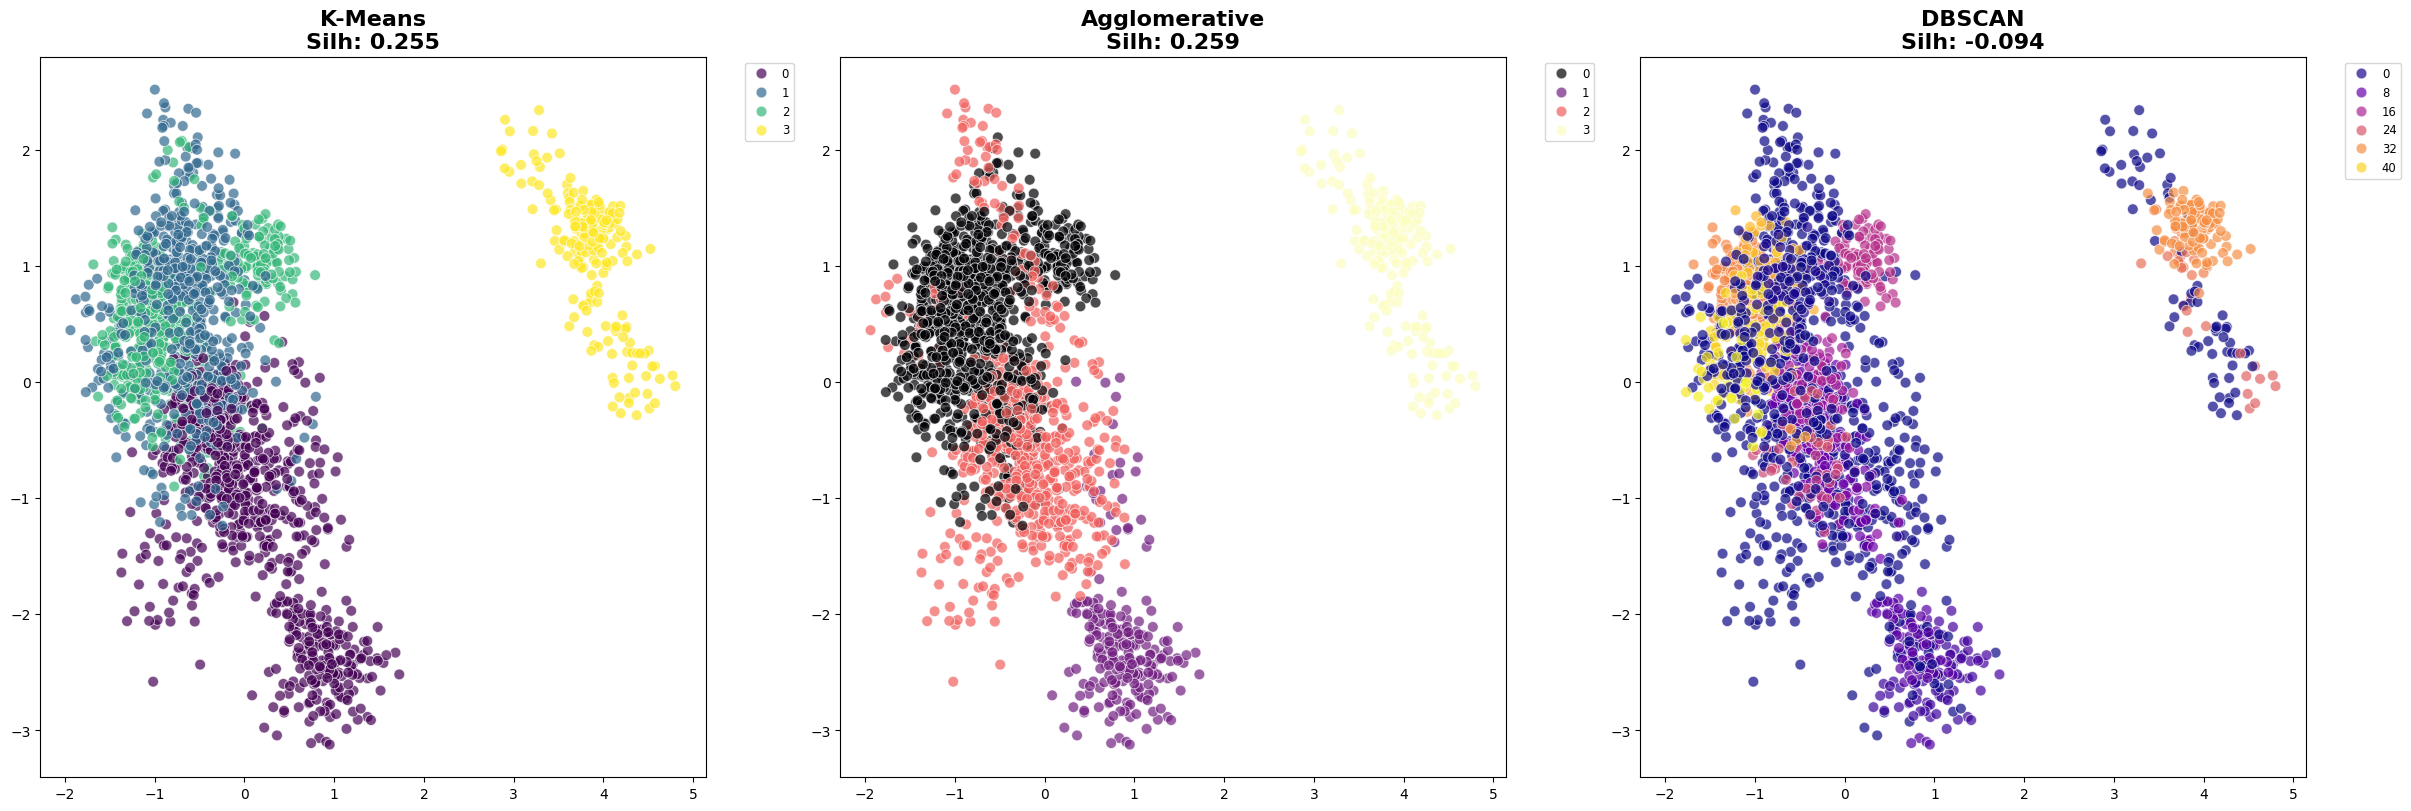

In [7]:
# 2. Setup the Figure with a MUCH larger width and constrained layout
# Note: layout="constrained" is the modern way to fix overlapping
fig, axes = plt.subplots(1, 3, figsize=(24, 8), layout="constrained")

# Helper function to plot each subplot
def plot_cluster(ax, labels, title, palette):
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, 
                    palette=palette, ax=ax, s=60, alpha=0.7)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)

# Plot K-Means
plot_cluster(axes[0], labels_kmeans, f"K-Means\nSilh: {cluster_results['K-Means']['Silhouette']:.3f}", 'viridis')

# Plot Agglomerative
plot_cluster(axes[1], labels_agg, f"Agglomerative\nSilh: {cluster_results['Agglomerative']['Silhouette']:.3f}", 'magma')

# Plot DBSCAN
plot_cluster(axes[2], labels_dbscan, f"DBSCAN\nSilh: {cluster_results['DBSCAN']['Silhouette']:.3f}", 'plasma')

plt.show()

In [8]:
import pickle  # This fixes the NameError

# 1. Save the Scaler
# Replace 'scaler' with the actual name of your scaler variable if it's different
try:
    with open('soil_scaler.pkl', 'wb') as file:
        pickle.dump(scaler, file)
    print("Success: soil_scaler.pkl saved to your project folder!")
except NameError:
    print("Error: The variable 'scaler' wasn't found. Check the name of your MinMaxScaler/StandardScaler variable.")

# 2. Save the KMeans Model
try:
    with open('soil_cluster_model.pkl', 'wb') as file:
        pickle.dump(labels_kmeans, file)
    print("Success: soil_cluster_model.pkl saved to your project folder!")
except NameError:
    print("Error: The variable 'soil_kmeans' wasn't found. Check what you named your KMeans model.")

Success: soil_scaler.pkl saved to your project folder!
Success: soil_cluster_model.pkl saved to your project folder!


In [9]:
import pickle

# 1. Save the K-Means Model from your dictionary
# Use models["K-Means"] because that is where the fitted object lives
with open('soil_cluster_model.pkl', 'wb') as file:
    pickle.dump(models["K-Means"], file)

# 2. Save the Scaler (make sure your scaler variable is named 'scaler' or 'X_scaled's creator)
with open('soil_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file) 

print("Success! Both files saved. Now move them to your /models/ folder.")

Success! Both files saved. Now move them to your /models/ folder.
